# Lifecycle Carbon Footprint of Electricity Generation Technologies


This notebook compares lifecycle greenhouse gas emissions across 7 electricity generation technologies using IPCC AR6 data, analyses China's grid decarbonisation trajectory, and models avoided emissions from renewable deployment in the Greater Bay Area.

**Framework:** GHG Protocol / ISO 14040-44 Lifecycle Assessment  
**Data:** IPCC AR6 WGIII Annex III, China Electricity Council, MEE Grid Emission Factors

In [1]:
import sys
sys.path.insert(0, '../scripts')
from lca_calculation import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
})

lca_df = build_lca_dataframe()
grid_df = calculate_grid_intensity_series()
print('LCA data loaded:', len(lca_df), 'technologies')
print('Grid intensity data:', len(grid_df), 'years')

LCA data loaded: 7 technologies
Grid intensity data: 10 years


## 1. Lifecycle Emission Factor Comparison

Full lifecycle emissions including construction, fuel supply chain, operation, and decommissioning. Coal and gas dominate due to combustion-phase emissions.

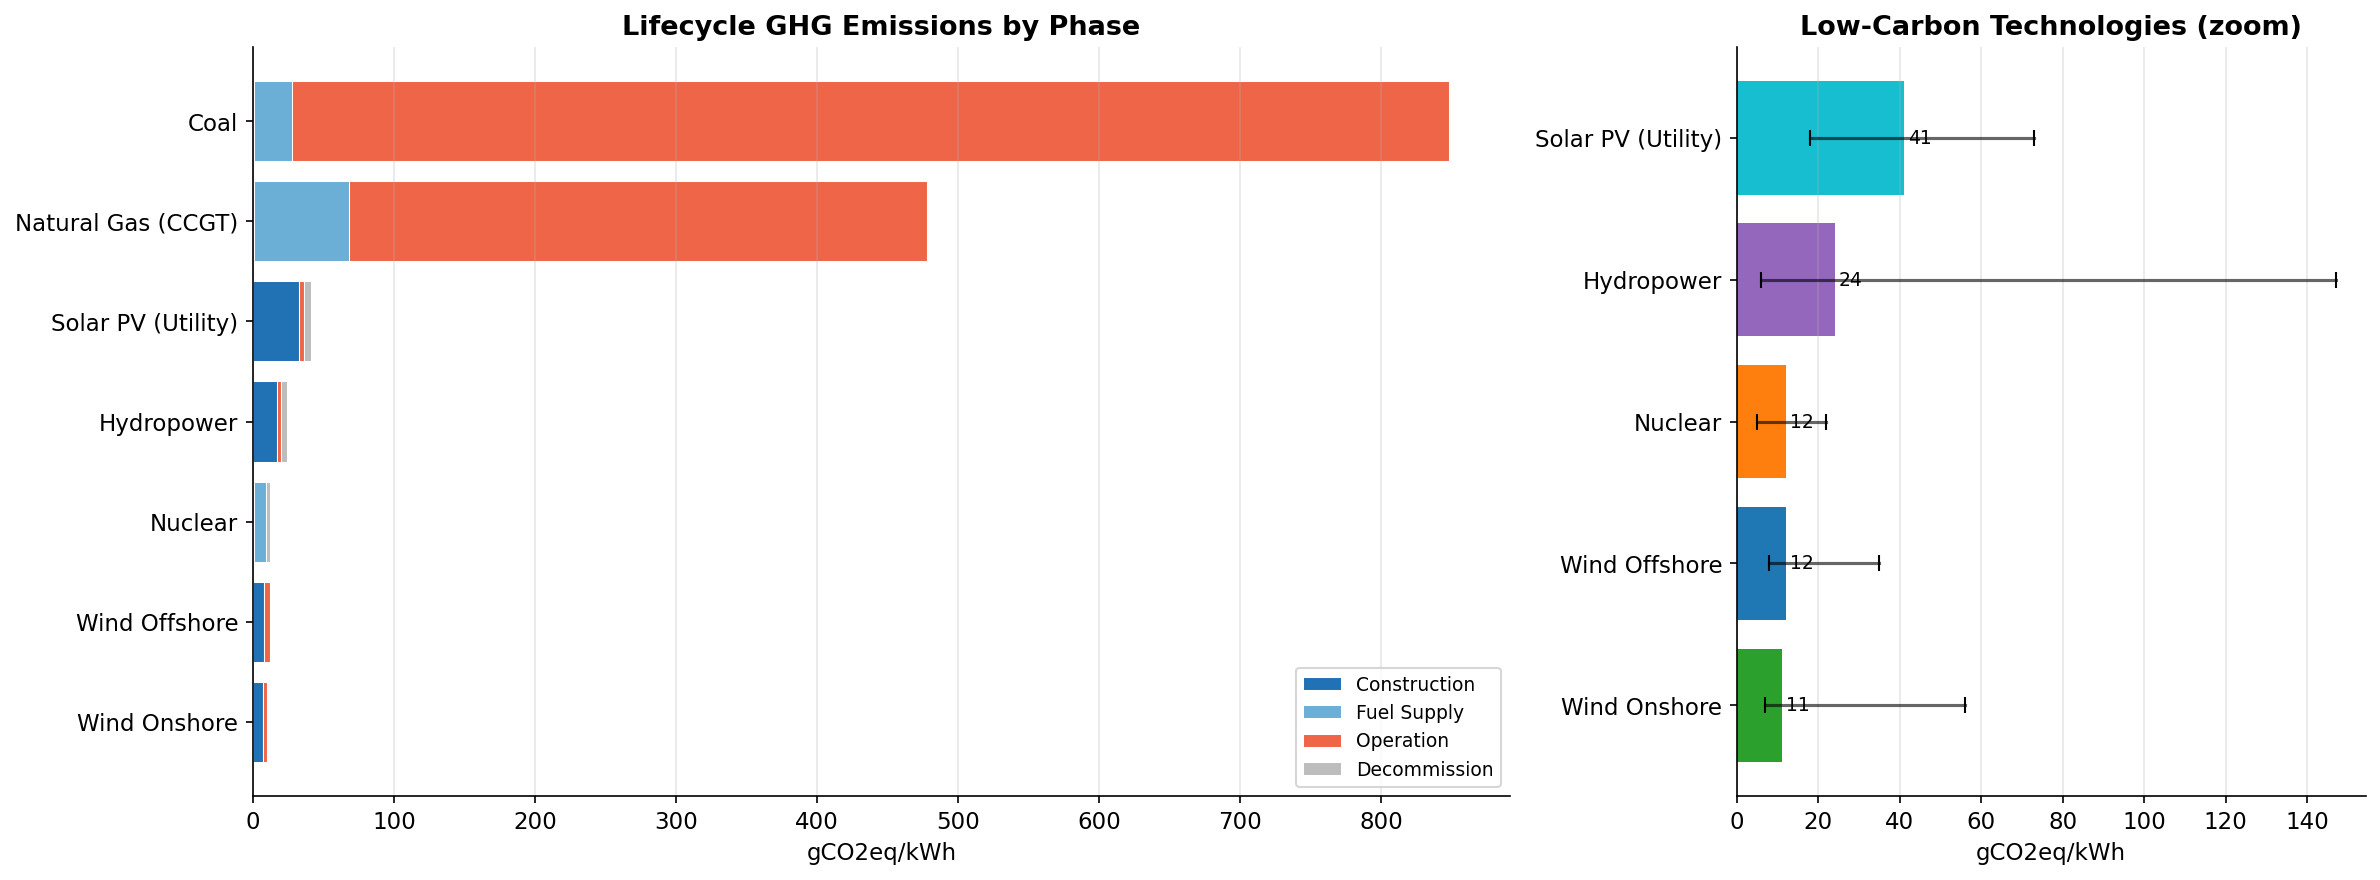


Coal lifecycle emissions are ~75x higher than wind/nuclear per kWh.
Even accounting for manufacturing, solar PV emits <5% of coal per kWh.


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [2, 1]})

# Left: stacked bar of lifecycle phases
ax = axes[0]
techs = lca_df.sort_values('total_median', ascending=True)['technology'].values
phases = ['construction', 'fuel_supply', 'operation', 'decommission']
colors = ['#2171b5', '#6baed6', '#ef6548', '#bdbdbd']

y_pos = np.arange(len(techs))
left = np.zeros(len(techs))

for phase, color in zip(phases, colors):
    vals = [lca_df[lca_df['technology'] == t][phase].values[0] for t in techs]
    ax.barh(y_pos, vals, left=left, color=color, label=phase.replace('_', ' ').title(),
            edgecolor='white', linewidth=0.5)
    left += vals

ax.set_yticks(y_pos)
ax.set_yticklabels(techs)
ax.set_xlabel('gCO2eq/kWh')
ax.set_title('Lifecycle GHG Emissions by Phase', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)

# Right: zoom on low-carbon technologies
ax2 = axes[1]
low_carbon = lca_df[lca_df['total_median'] < 100].sort_values('total_median', ascending=True)
colors_lc = ['#2ca02c', '#1f77b4', '#ff7f0e', '#9467bd', '#17becf']

bars = ax2.barh(low_carbon['technology'], low_carbon['total_median'], color=colors_lc[:len(low_carbon)])

# Add uncertainty ranges
for i, (_, row) in enumerate(low_carbon.iterrows()):
    ax2.plot([row['range_low'], row['range_high']], [i, i], 'k-', linewidth=1.5, alpha=0.6)
    ax2.plot([row['range_low']], [i], 'k|', markersize=8)
    ax2.plot([row['range_high']], [i], 'k|', markersize=8)

ax2.set_xlabel('gCO2eq/kWh')
ax2.set_title('Low-Carbon Technologies (zoom)', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

for bar, (_, row) in zip(bars, low_carbon.iterrows()):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{row["total_median"]:.0f}', va='center', fontsize=9)

sns.despine()
plt.tight_layout()
plt.savefig('../outputs/lifecycle_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

print('\nCoal lifecycle emissions are ~75x higher than wind/nuclear per kWh.')
print('Even accounting for manufacturing, solar PV emits <5% of coal per kWh.')

## 2. China Grid Decarbonisation Trajectory (2015-2024)

Tracking how China's electricity mix and resulting grid emission intensity have evolved.

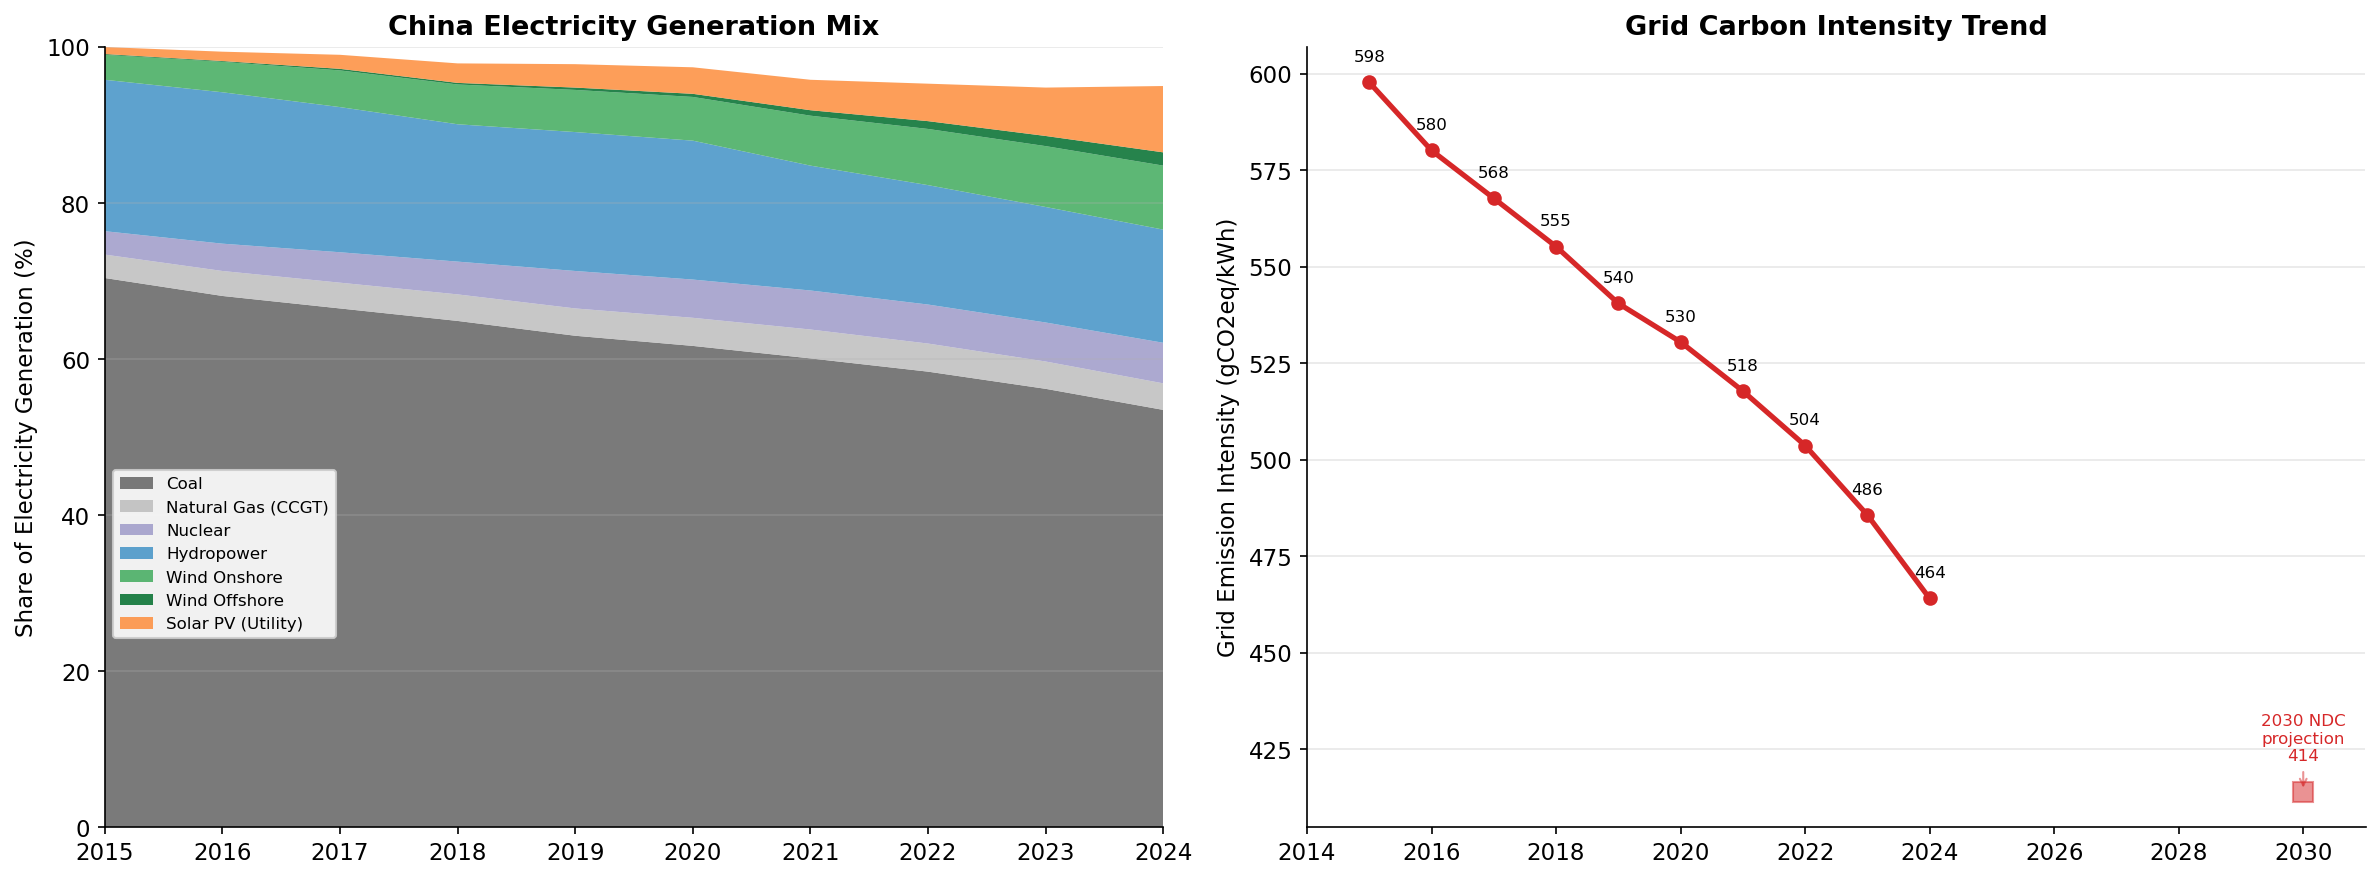

Grid intensity declined 134 gCO2eq/kWh (-22.4%) from 2015 to 2024
Coal share dropped from 70.4% to 53.5%
Renewable share grew from 23.6% to 32.9%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: stacked area of grid mix
ax = axes[0]
years = sorted(CHINA_GRID_MIX.keys())
tech_order = ['Coal', 'Natural Gas (CCGT)', 'Nuclear', 'Hydropower',
              'Wind Onshore', 'Wind Offshore', 'Solar PV (Utility)']
colors_mix = ['#636363', '#bdbdbd', '#9e9ac8', '#4292c6',
              '#41ab5d', '#006d2c', '#fd8d3c']

mix_data = {tech: [CHINA_GRID_MIX[y][tech] for y in years] for tech in tech_order}
ax.stackplot(years, *[mix_data[t] for t in tech_order],
             labels=tech_order, colors=colors_mix, alpha=0.85)
ax.set_ylabel('Share of Electricity Generation (%)')
ax.set_title('China Electricity Generation Mix', fontweight='bold')
ax.legend(loc='center left', bbox_to_anchor=(0, 0.35), fontsize=8, framealpha=0.9)
ax.set_xlim(2015, 2024)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

# Right: grid intensity trend
ax2 = axes[1]
ax2.plot(grid_df['year'], grid_df['grid_intensity_gCO2eq_kWh'],
         'o-', color='#d62728', linewidth=2.5, markersize=6, label='Grid Intensity')

# Annotate values
for _, row in grid_df.iterrows():
    ax2.annotate(f'{row["grid_intensity_gCO2eq_kWh"]:.0f}',
                (row['year'], row['grid_intensity_gCO2eq_kWh']),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=8)

# 2030 projection
mix_2030, intensity_2030 = scenario_china_2030()
ax2.plot(2030, intensity_2030, 's', color='#d62728', markersize=10, alpha=0.5)
ax2.annotate(f'2030 NDC\nprojection\n{intensity_2030:.0f}',
            (2030, intensity_2030), textcoords='offset points',
            xytext=(0, 15), ha='center', fontsize=8, color='#d62728',
            arrowprops=dict(arrowstyle='->', color='#d62728', alpha=0.5))

ax2.set_ylabel('Grid Emission Intensity (gCO2eq/kWh)')
ax2.set_title('Grid Carbon Intensity Trend', fontweight='bold')
ax2.set_xlim(2014, 2031)
ax2.grid(axis='y', alpha=0.3)

sns.despine()
plt.tight_layout()
plt.savefig('../outputs/grid_decarbonisation.png', dpi=200, bbox_inches='tight')
plt.show()

decline = (grid_df.iloc[-1]['grid_intensity_gCO2eq_kWh'] - grid_df.iloc[0]['grid_intensity_gCO2eq_kWh'])
pct = decline / grid_df.iloc[0]['grid_intensity_gCO2eq_kWh'] * 100
print(f'Grid intensity declined {abs(decline):.0f} gCO2eq/kWh ({pct:.1f}%) from 2015 to 2024')
print(f'Coal share dropped from {grid_df.iloc[0]["coal_share_pct"]}% to {grid_df.iloc[-1]["coal_share_pct"]}%')
print(f'Renewable share grew from {grid_df.iloc[0]["renewable_share_pct"]}% to {grid_df.iloc[-1]["renewable_share_pct"]}%')

## 3. Avoided Emissions: Renewable Deployment Scenarios

Modelling net avoided CO2 emissions from deploying 100MW of solar PV and wind in the South China Grid (GBA region) vs national average.

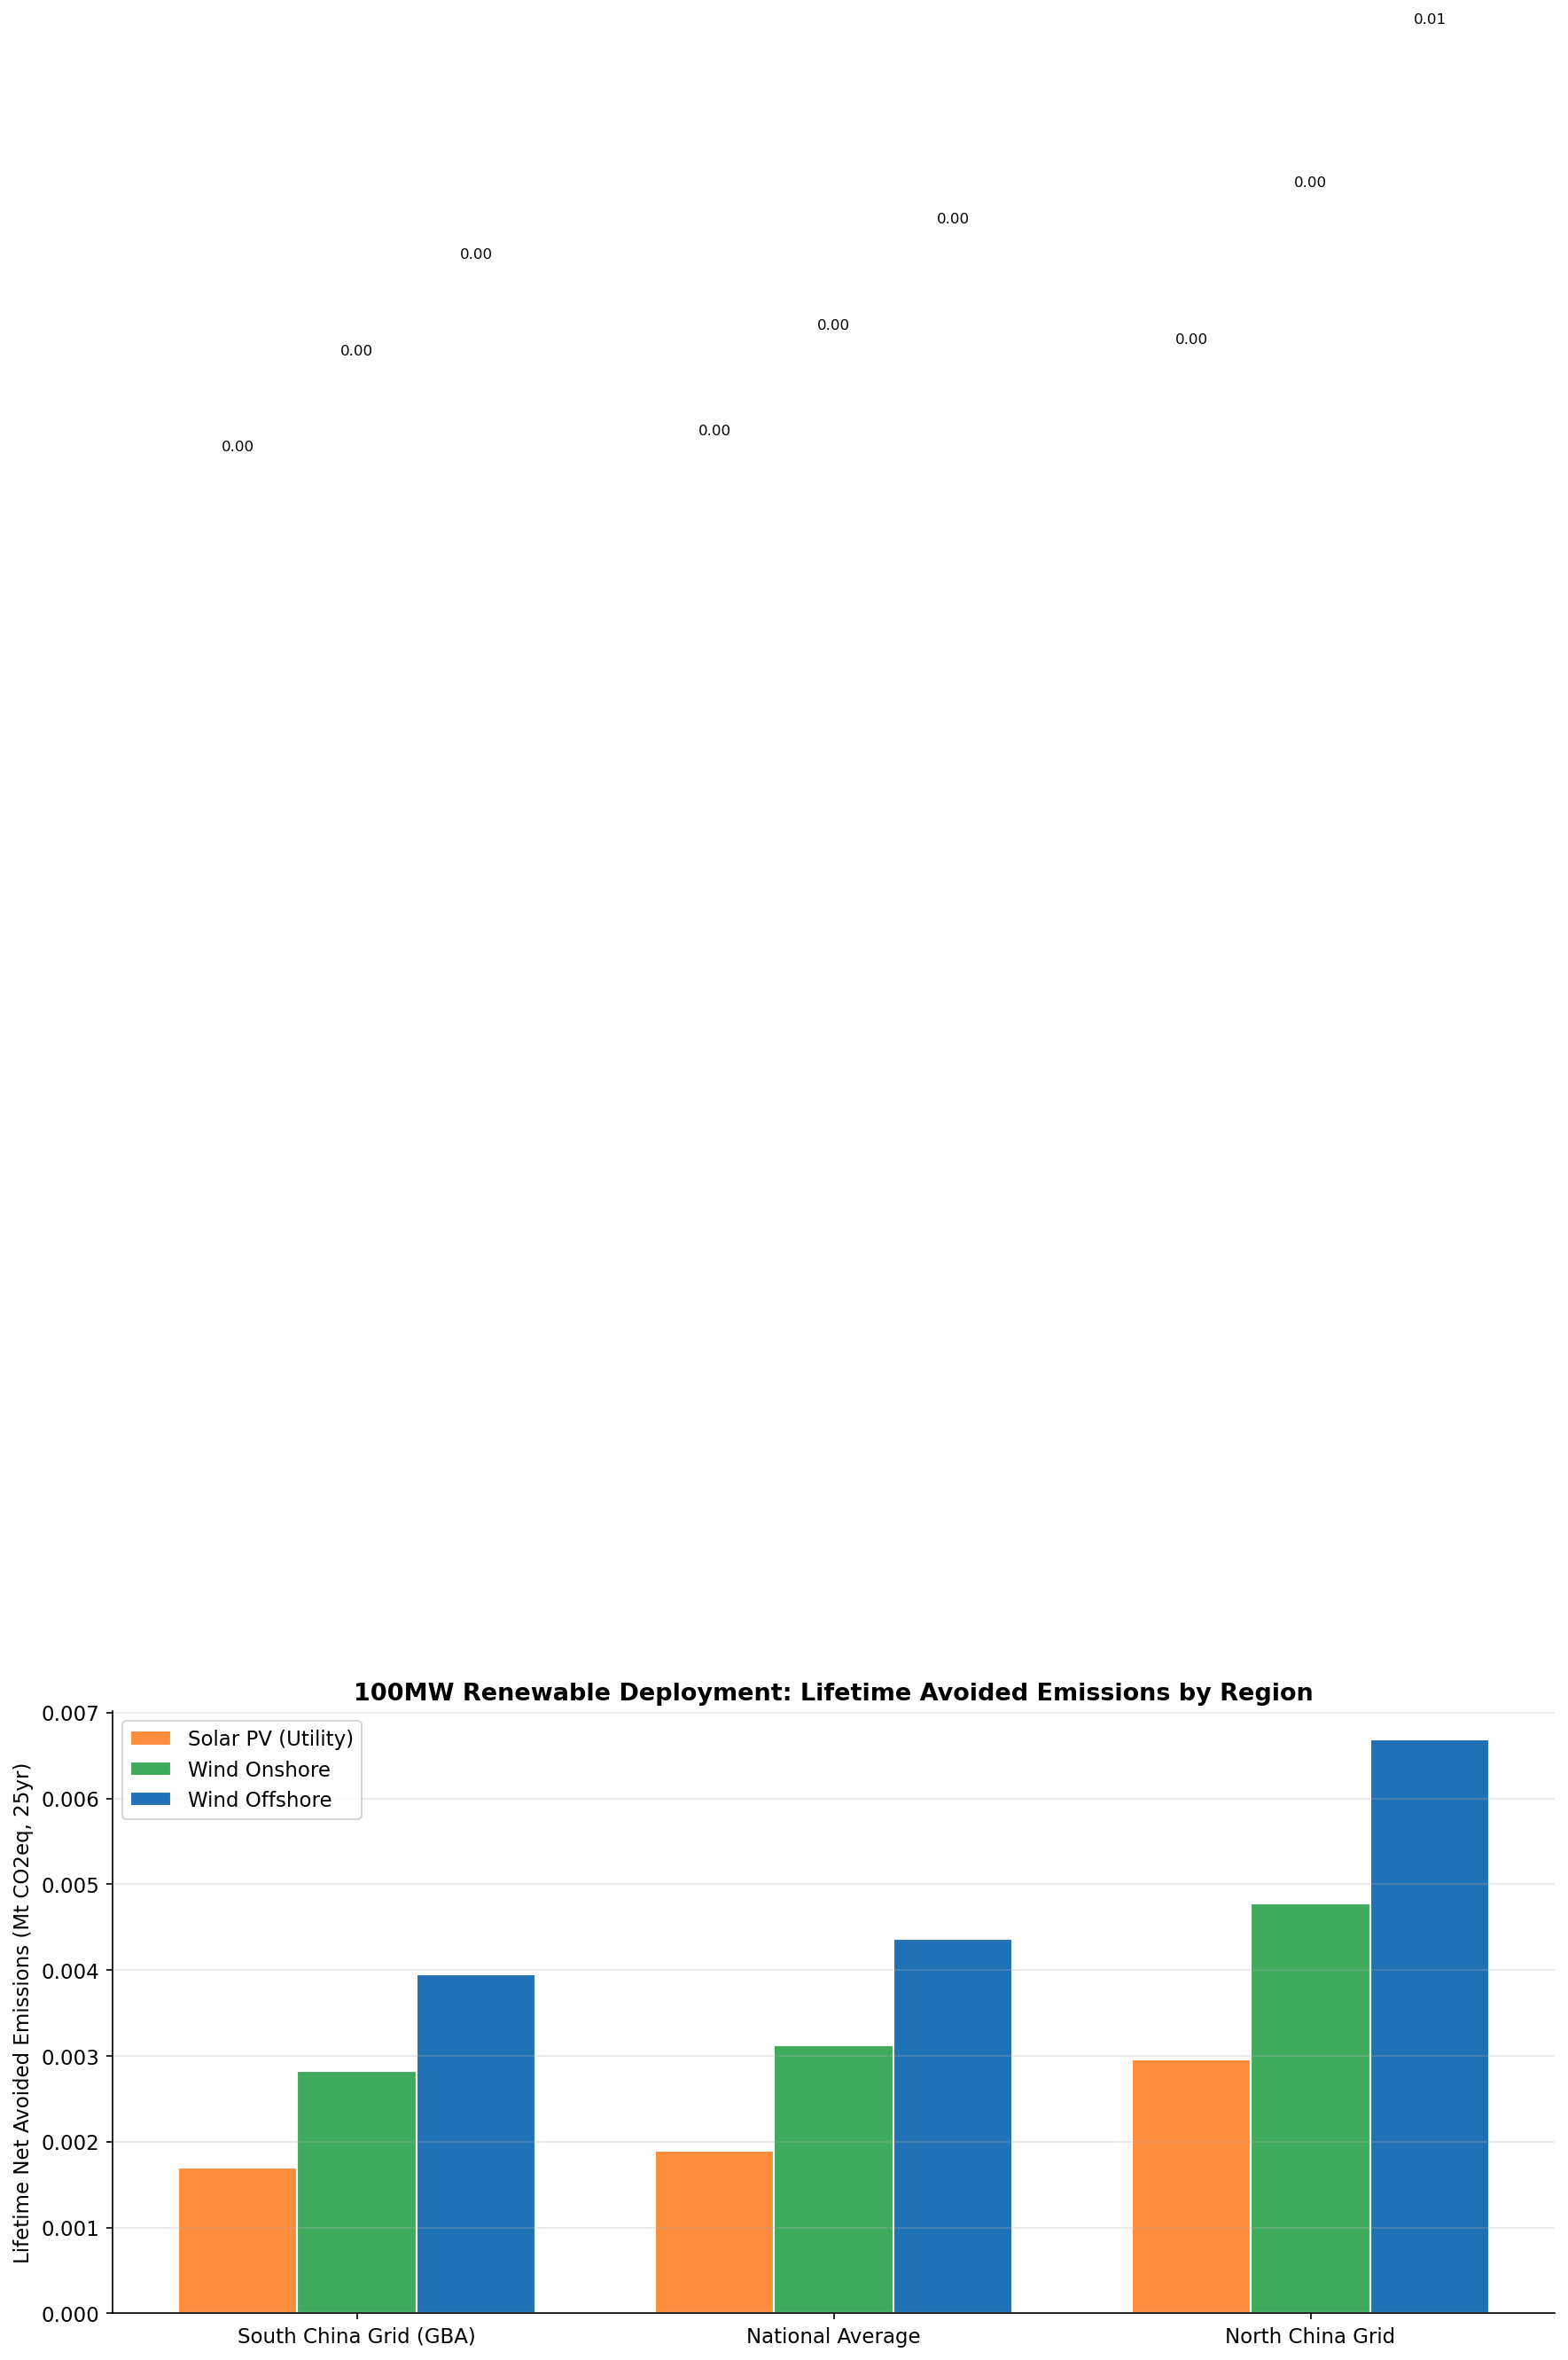

Key insight: Same 100MW deployment avoids ~60% more CO2 in North China (coal-heavy)
than in South China Grid (more hydro), highlighting regional dispatch effects.


In [4]:
scenarios = []
for region, ef in [('South China Grid (GBA)', REGIONAL_GRID_EF['南方区域电网']),
                    ('National Average', REGIONAL_GRID_EF['全国平均']),
                    ('North China Grid', REGIONAL_GRID_EF['华北区域电网'])]:
    for tech, cf in [('Solar PV (Utility)', 0.16), ('Wind Onshore', 0.25), ('Wind Offshore', 0.35)]:
        result = calculate_avoided_emissions(100, tech, cf, ef * 1000)
        result['region'] = region
        scenarios.append(result)

sc_df = pd.DataFrame(scenarios)

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(3)  # 3 regions
width = 0.25
regions = ['South China Grid (GBA)', 'National Average', 'North China Grid']
techs_plot = ['Solar PV (Utility)', 'Wind Onshore', 'Wind Offshore']
colors_sc = ['#fd8d3c', '#41ab5d', '#2171b5']

for i, tech in enumerate(techs_plot):
    vals = [sc_df[(sc_df['region'] == r) & (sc_df['technology'] == tech)]['lifetime_net_avoided_tCO2'].values[0]
            for r in regions]
    bars = ax.bar(x + i * width, [v / 1e6 for v in vals], width,
                  label=tech, color=colors_sc[i], edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{v/1e6:.2f}', ha='center', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(regions)
ax.set_ylabel('Lifetime Net Avoided Emissions (Mt CO2eq, 25yr)')
ax.set_title('100MW Renewable Deployment: Lifetime Avoided Emissions by Region', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('../outputs/avoided_emissions.png', dpi=200, bbox_inches='tight')
plt.show()

print('Key insight: Same 100MW deployment avoids ~60% more CO2 in North China (coal-heavy)')
print('than in South China Grid (more hydro), highlighting regional dispatch effects.')

## 4. Regional Grid Emission Factor Map

China's 6 regional grids have very different emission intensities, reflecting local generation mix.

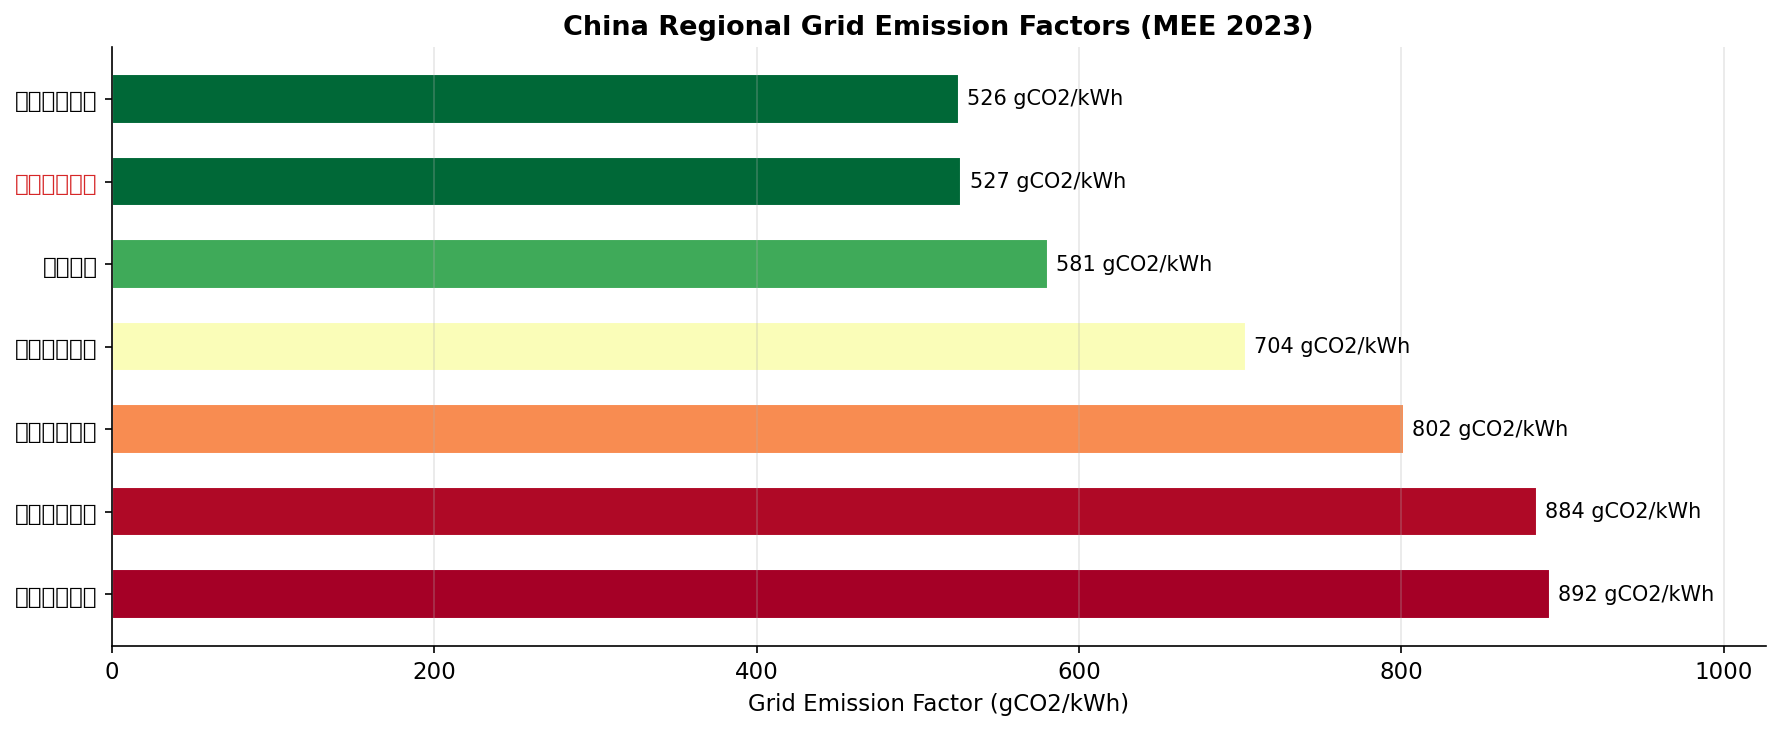

GBA (South China Grid) has the 2nd lowest grid EF at 527 gCO2/kWh,
benefiting from Yunnan/Guizhou hydropower transmission (西电东送).


In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

regions_sorted = sorted(REGIONAL_GRID_EF.items(), key=lambda x: x[1], reverse=True)
names = [r[0] for r in regions_sorted]
values = [r[1] * 1000 for r in regions_sorted]  # convert to gCO2/kWh

# Color by intensity
cmap = plt.cm.RdYlGn_r
norm = plt.Normalize(min(values), max(values))
bar_colors = [cmap(norm(v)) for v in values]

bars = ax.barh(names, values, color=bar_colors, edgecolor='white', height=0.6)

for bar, v in zip(bars, values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{v:.0f} gCO2/kWh', va='center', fontsize=10)

# Highlight South China (GBA)
for i, name in enumerate(names):
    if name == '南方区域电网':
        ax.get_yticklabels()[i].set_fontweight('bold')
        ax.get_yticklabels()[i].set_color('#d62728')

ax.set_xlabel('Grid Emission Factor (gCO2/kWh)')
ax.set_title('China Regional Grid Emission Factors (MEE 2023)', fontweight='bold')
ax.set_xlim(0, max(values) * 1.15)
ax.grid(axis='x', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('../outputs/regional_grid_ef.png', dpi=200, bbox_inches='tight')
plt.show()

print('GBA (South China Grid) has the 2nd lowest grid EF at 527 gCO2/kWh,')
print('benefiting from Yunnan/Guizhou hydropower transmission (西电东送).')

## 5. Carbon Payback Period

How long does it take for a renewable energy installation to "pay back" the carbon emitted during its manufacturing and construction?

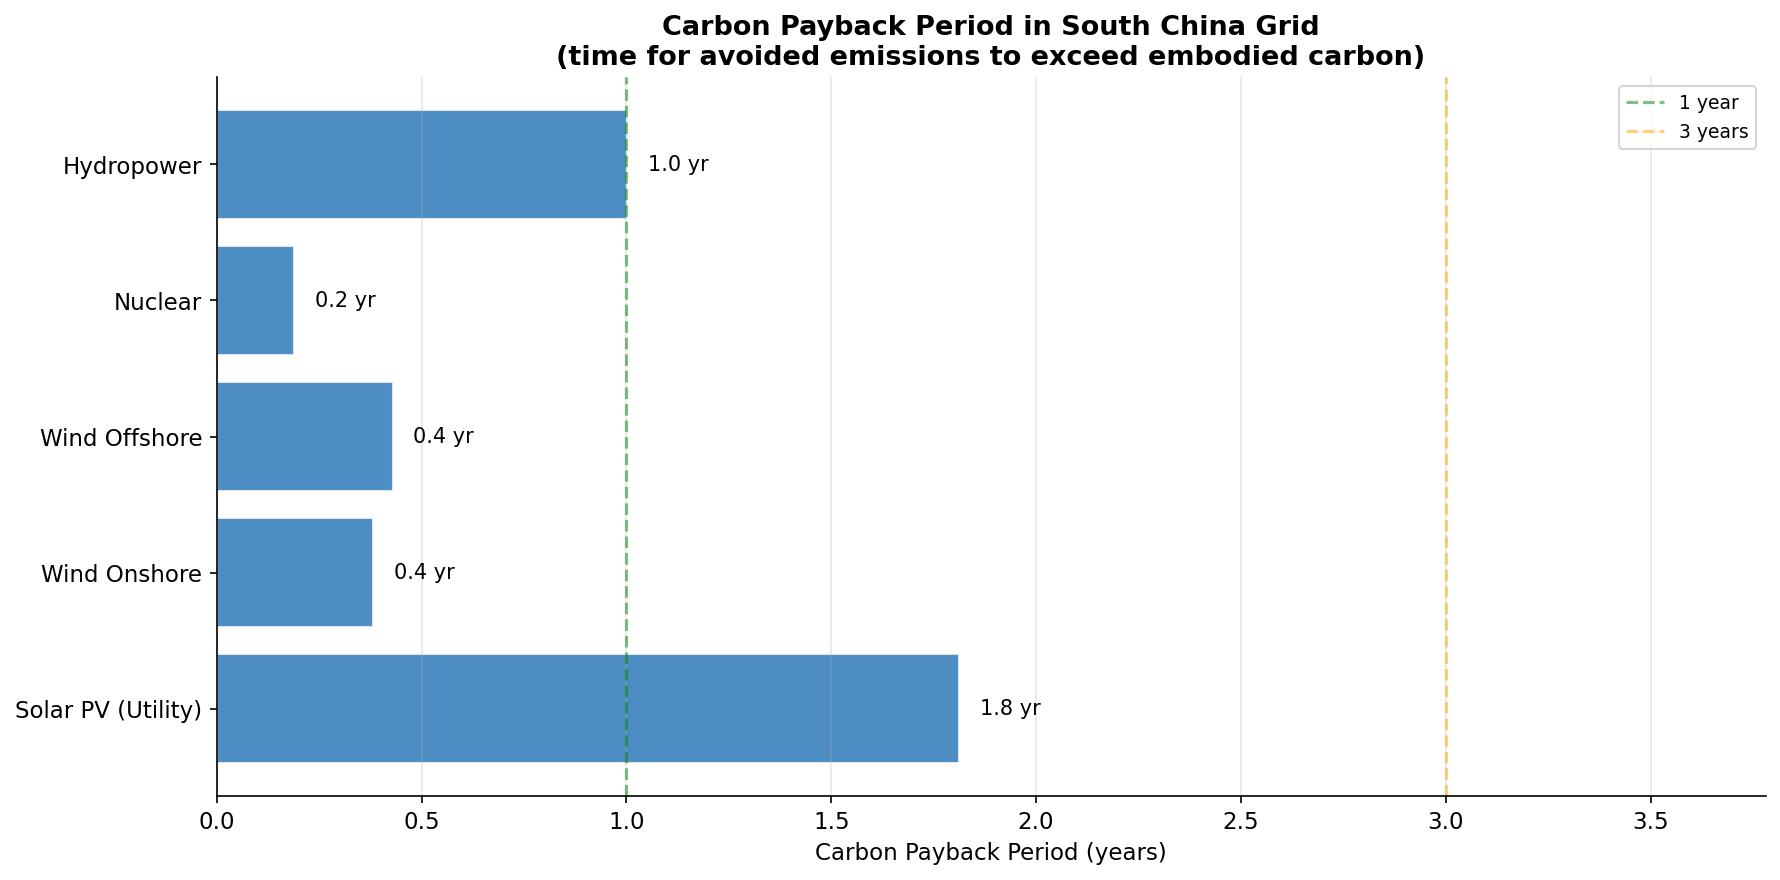

All renewable technologies pay back their embodied carbon within 1-2 years,
generating net-negative emissions for the remaining 23+ years of operation.


In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

renewables = ['Solar PV (Utility)', 'Wind Onshore', 'Wind Offshore', 'Nuclear', 'Hydropower']
capacity_factors = {'Solar PV (Utility)': 0.16, 'Wind Onshore': 0.25,
                    'Wind Offshore': 0.35, 'Nuclear': 0.85, 'Hydropower': 0.40}
grid_ef = REGIONAL_GRID_EF['南方区域电网'] * 1000  # gCO2/kWh

for tech in renewables:
    data = LIFECYCLE_FACTORS[tech]
    embodied = data['construction'] + data['decommission']  # gCO2eq/kWh over lifetime
    # Avoided per kWh = grid_ef - operation_ef
    avoided_per_kwh = grid_ef - data['operation']
    # Payback in kWh: embodied_total / avoided_per_kwh
    # Convert to years: assume capacity factor
    cf = capacity_factors[tech]
    hours_per_year = 8760 * cf
    # embodied is gCO2eq per kWh of lifetime generation
    # Total embodied per kW = embodied * hours_per_year * lifetime / 1000... 
    # Simpler: payback_years = (embodied_gCO2_per_kWh * lifetime_hours) / (avoided_per_kWh * hours_per_year)
    # Actually: embodied is already per kWh of lifetime output
    # So payback ratio = embodied / avoided_per_kwh (fraction of lifetime)
    lifetime = 25
    payback_years = (embodied / avoided_per_kwh) * lifetime
    
    ax.barh(tech, payback_years, color='#2171b5', alpha=0.8, edgecolor='white')
    ax.text(payback_years + 0.05, tech, f'{payback_years:.1f} yr', va='center', fontsize=10)

ax.set_xlabel('Carbon Payback Period (years)')
ax.set_title('Carbon Payback Period in South China Grid\n(time for avoided emissions to exceed embodied carbon)',
             fontweight='bold')
ax.axvline(x=1, color='green', linestyle='--', alpha=0.5, label='1 year')
ax.axvline(x=3, color='orange', linestyle='--', alpha=0.5, label='3 years')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, max(3, ax.get_xlim()[1]) * 1.2)
sns.despine()
plt.tight_layout()
plt.savefig('../outputs/carbon_payback.png', dpi=200, bbox_inches='tight')
plt.show()

print('All renewable technologies pay back their embodied carbon within 1-2 years,')
print('generating net-negative emissions for the remaining 23+ years of operation.')

## Key Conclusions

1. **Fossil fuels dominate lifecycle emissions**: Coal emits 820 gCO2eq/kWh (median), ~75x more than wind or nuclear on a lifecycle basis.

2. **China's grid is decarbonising steadily**: Coal's share dropped from 70% to 54% (2015-2024), and solar PV grew from <1% to 8.5%.

3. **Regional grid composition matters for carbon accounting**: The South China Grid (GBA) has ~40% lower emission intensity than North China, due to hydropower imports.

4. **Carbon payback is rapid**: Solar PV and wind installations recoup their embodied carbon within ~1-2 years, generating net climate benefits for 23+ years.

5. **Policy implication**: Renewable deployment in coal-heavy northern grids displaces ~60% more CO2 per MW than in southern grids — a key consideration for national carbon market offset projects (CCER).

---